# Занятие 23. Конструирование признаков

Модель не видит квартиру, клиента или дату — она видит **столбцы чисел**. **Конструирование признаков** (feature engineering) — превращение исходных данных в такие столбцы, из которых модели легче извлечь закономерность.

К концу занятия вы сможете:

- отличать безопасный признак от утечки и «признака из будущего»;
- строить числовые, категориальные и временные признаки;
- обрабатывать пропуски и неизвестные категории без утечки;
- честно проверять пользу нового признака на validation.

**Сквозной пример.** Все разделы работают с одной таблицей: объявления о продаже квартир, цель — предсказать **цену** (млн руб.). Один объект — одно объявление. Сразу делим на train и validation (70 % / 30 %), как на занятии 21: всё, что «обучается» по данным, будем считать только на train.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

flats = pd.DataFrame({
    'площадь': [35, 50, 80, 120, 42, 28, 95, 60, 33, 75, 55, 110, 38, 68, 47],
    'комнаты': [1, 2, 3, 4, 1, 1, 3, 2, 1, 3, 2, 4, 1, 2, 2],
    'район': ['центр', 'спальный', 'центр', 'пригород', 'спальный',
              'центр', 'пригород', 'спальный', 'центр', 'спальный',
              'пригород', 'центр', 'спальный', 'исторический', 'спальный'],
    'состояние': ['хорошее', 'среднее', 'хорошее', 'требует ремонта', 'среднее',
                  'хорошее', 'среднее', 'хорошее', 'требует ремонта', 'среднее',
                  'хорошее', 'хорошее', 'среднее', 'хорошее', 'требует ремонта'],
    'балкон': [0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    'дата': pd.to_datetime(['2026-01-10', '2026-02-15', '2026-06-01', '2026-03-20',
                            '2026-01-25', '2026-04-05', '2026-02-08', '2026-05-12',
                            '2026-03-03', '2026-06-18', '2026-04-22', '2026-05-30',
                            '2026-01-17', '2026-02-27', '2026-06-09']),
    'просмотры_за_месяц': [120, 45, 300, 15, 60, 800, 25, 90, 40, 150,
                           55, 2500, 35, 70, 5000],
    'доход_района': [95, 60, np.nan, 45, 62, 90, np.nan, 58, 88, 61,
                     47, 97, np.nan, 85, 59],
    'цена': [7.2, 9.8, 17.5, 18.0, 8.1, 6.5, 15.2, 11.0, 6.9, 14.0,
             9.0, 24.0, 7.6, 13.5, 8.8],
})

flats_train, flats_val = train_test_split(flats, test_size=0.3, random_state=42)
print('Объектов:', len(flats), '| train:', len(flats_train), '| validation:', len(flats_val))
flats.head()


Объектов: 15 | train: 10 | validation: 5


,площадь,комнаты,район,состояние,балкон,дата,просмотры_за_месяц,доход_района,цена
0,35,1,центр,хорошее,0,2026-01-10,120,95.0,7.2
1,50,2,спальный,среднее,1,2026-02-15,45,60.0,9.8
2,80,3,центр,хорошее,1,2026-06-01,300,NaN,17.5
3,120,4,пригород,требует ремонта,1,2026-03-20,15,45.0,18.0
4,42,1,спальный,среднее,0,2026-01-25,60,62.0,8.1


## 1. Что делает признак хорошим

**Признак** — столбец таблицы, который модель использует как вход. **Момент прогноза** — момент, когда модель должна дать ответ; для нашей задачи это момент публикации объявления.

Хороший признак:

1. **известен в момент прогноза** — «дата продажи» не годится: её ещё нет;
2. **не содержит цель** — «цена за метр» = цена / площадь, а цену мы и предсказываем;
3. **одинаково вычисляется** для train и новых объявлений;
4. **связан с задачей по смыслу** — есть гипотеза, почему он влияет на цену;
5. **устойчив** — не ломается от одного нового объекта.

Нарушение пп. 1–2 называется **утечкой** (занятие 21): модель получает информацию, которой в реальности не будет, и validation-оценка становится обманчиво хорошей.

## 2. Отношения и разности

Комбинация двух столбцов часто информативнее каждого по отдельности:

- **отношение** — `площадь / комнаты`: просторность жилья; 80 м² на 3 комнаты и 80 м² на 1 комнату — разные квартиры;
- **разность** — например, «доход района − средний доход по городу»: насколько район богаче типичного.

Оба признака известны в момент публикации — безопасны.

In [16]:
flats['площадь_на_комнату'] = flats['площадь'] / flats['комнаты']
flats[['площадь', 'комнаты', 'площадь_на_комнату', 'цена']].head()


,площадь,комнаты,площадь_на_комнату,цена
0,35,1,35.000000,7.2
1,50,2,25.000000,9.8
2,80,3,26.666667,17.5
3,120,4,30.000000,18.0
4,42,1,42.000000,8.1


## 3. Логарифмирование скошенных величин

`просмотры_за_месяц` распределены **скошенно**: у большинства объявлений десятки просмотров, у пары «вирусных» — тысячи. Модели, чувствительные к масштабу (kNN, линейные), будут ориентироваться в основном на выбросы.

`np.log1p(x)` = log(1 + x) сжимает большие значения и не ломается на нуле. Порядок объектов сохраняется, а разрывы уменьшаются.

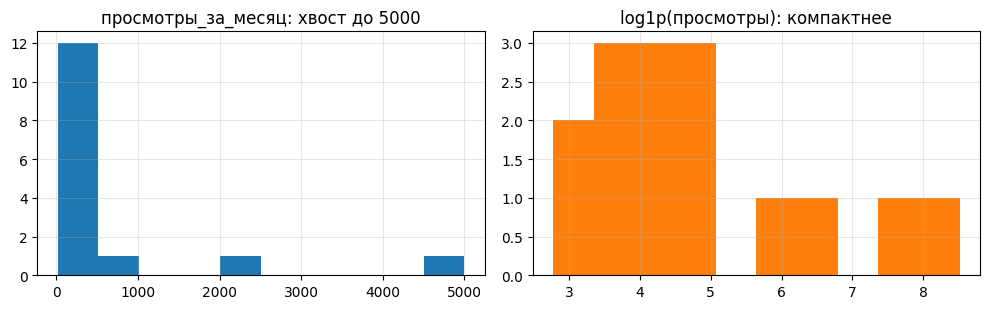

In [17]:
flats['log_просмотры'] = np.log1p(flats['просмотры_за_месяц'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(flats['просмотры_за_месяц'], bins=10)
axes[0].set_title('просмотры_за_месяц: хвост до 5000')
axes[1].hist(flats['log_просмотры'], bins=10, color='tab:orange')
axes[1].set_title('log1p(просмотры): компактнее')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Интервалы и ограничение выбросов

Иногда важна не точная площадь, а **класс** жилья: малогабаритное / стандартное / просторное. `pd.cut` превращает число в интервал — линейной модели проще выучить пороговые эффекты.

Экстремальные значения (те же 5000 просмотров) можно **ограничить** разумной границей (`clip`). Но сначала проверьте смысл: настоящий редкий объект — не ошибка, и обрезать его стоит только если он мешает модели.

In [18]:
flats['класс_площади'] = pd.cut(
    flats['площадь'], bins=[0, 40, 80, 200],
    labels=['малогабаритная', 'стандартная', 'просторная'],
)
flats['просмотры_clip'] = flats['просмотры_за_месяц'].clip(upper=500)
flats[['площадь', 'класс_площади', 'просмотры_за_месяц', 'просмотры_clip']].head()


,площадь,класс_площади,просмотры_за_месяц,просмотры_clip
0,35,малогабаритная,120,120
1,50,стандартная,45,45
2,80,стандартная,300,300
3,120,просторная,15,15
4,42,стандартная,60,60


## 5. Нелинейность и взаимодействия

Линейная модель (см. следующую тему) складывает вклады признаков по отдельности. Новые столбцы позволяют ей описывать более сложные связи:

- $x^2$ — изгиб (нелинейность) зависимости;
- $x_1 \cdot x_2$ — **взаимодействие**: влияние одного признака зависит от другого; признаки перемножаются, а не складываются;
- интервалы (как описано в предыдущем пункте) — разные «режимы».

Гипотеза для нашей таблицы: балкон добавляет к цене тем больше, чем больше квартира. Тогда полезен признак `площадь × балкон`.

Чем больше сгенерированных преобразований, тем выше риск **переобучения** — каждое добавление проверяем на validation (подробности ниже).

In [19]:
flats['площадь_x_балкон'] = flats['площадь'] * flats['балкон']
flats[['площадь', 'балкон', 'площадь_x_балкон']].head()


,площадь,балкон,площадь_x_балкон
0,35,0,0
1,50,1,50
2,80,1,80
3,120,1,120
4,42,0,0


## 6. Как увидеть пользу взаимодействия

Признак-взаимодействие нужен, когда на графике «признак → цель» **наклон зависит от группы**. Нарисуем цену против площади отдельно для квартир с балконом и без.

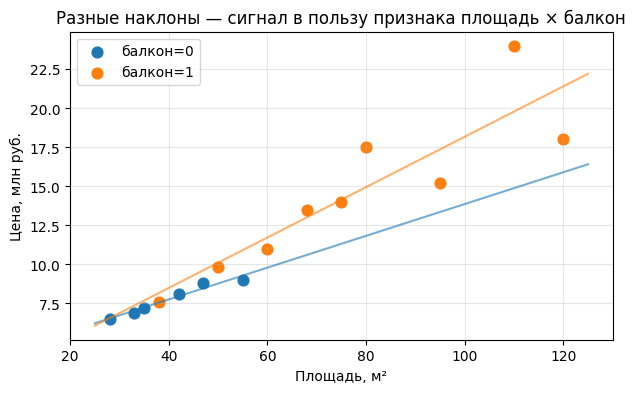

In [20]:
plt.figure(figsize=(7, 4))
for balcony_value, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
    subset = flats[flats['балкон'] == balcony_value]
    plt.scatter(subset['площадь'], subset['цена'], color=color,
                label=f'балкон={balcony_value}', s=60)
    k, b = np.polyfit(subset['площадь'], subset['цена'], deg=1)
    xs = np.linspace(25, 125, 50)
    plt.plot(xs, k * xs + b, color=color, alpha=0.6)
plt.xlabel('Площадь, м²'); plt.ylabel('Цена, млн руб.')
plt.title('Разные наклоны — сигнал в пользу признака площадь × балкон')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 7. Даты и цикличность *

Из `дата` объявления можно получить компоненты: год, **месяц**, день недели, признак выходного.

У циклических величин есть подвох: месяц 12 и месяц 1 — соседи, но числа 12 и 1 далеки. Пара признаков

$$\sin(2\pi m / 12), \qquad \cos(2\pi m / 12)$$

размещает месяцы на окружности: декабрь и январь оказываются рядом.

Раздел со звёздочкой: для начала достаточно компонентов даты и самой идеи цикличности.

In [21]:
flats['месяц'] = flats['дата'].dt.month
flats['день_недели'] = flats['дата'].dt.dayofweek
flats['месяц_sin'] = np.sin(2 * np.pi * flats['месяц'] / 12)
flats['месяц_cos'] = np.cos(2 * np.pi * flats['месяц'] / 12)
flats[['дата', 'месяц', 'день_недели', 'месяц_sin', 'месяц_cos']].head().round(2)


,дата,месяц,день_недели,месяц_sin,месяц_cos
0,2026-01-10,1,5,0.50,0.87
1,2026-02-15,2,6,0.87,0.50
2,2026-06-01,6,0,0.00,-1.00
3,2026-03-20,3,4,1.00,0.00
4,2026-01-25,1,6,0.50,0.87


## 8. Время с события

Часто полезнее не сама дата, а **сколько времени прошло**: дней с публикации объявления — «залежавшиеся» квартиры могут быть переоценены.

Обе даты в разности должны быть доступны в **момент прогноза**. Если «последнее событие» случилось позже момента прогноза — это утечка.

In [22]:
prediction_date = pd.Timestamp('2026-07-01')
flats['дней_с_публикации'] = (prediction_date - flats['дата']).dt.days
flats[['дата', 'дней_с_публикации']].head()


,дата,дней_с_публикации
0,2026-01-10,172
1,2026-02-15,136
2,2026-06-01,30
3,2026-03-20,103
4,2026-01-25,157


## 9. Категориальные признаки и one-hot

`район` — **категориальный** признак: значения «центр», «спальный», «пригород» нельзя заменить числами 1, 2, 3 — модель увидит несуществующий порядок (и даже если порядок имеет смысл, модель может использовать неправильно «расстояния» между районами).

**One-hot encoding** создаёт для каждой категории столбец 0/1: объект получает 1 в «своём» столбце. Кодировщик обучаем (`fit`) на train — как любое преобразование.

In [23]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_encoded = encoder.fit_transform(flats_train[['район']])
print('Столбцы:', list(encoder.get_feature_names_out()))
pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out()).head()


Столбцы: ['район_пригород', 'район_спальный', 'район_центр']


,район_пригород,район_спальный,район_центр
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


## 10. Порядковые категории

У `состояние` порядок настоящий: «требует ремонта» < «среднее» < «хорошее». **Ordinal encoding** сохраняет его числами 0, 1, 2 — важно задать порядок явно, а не доверять алфавиту.

Нюанс: линейная модель после такого кодирования считает шаг между уровнями **одинаковым**

(ремонт → среднее = среднее → хорошее). 

Если это не так по смыслу — сравните с one-hot на validation. Для района и цвета порядка нет вовсе — там ordinal вреден.

In [24]:
from sklearn.preprocessing import OrdinalEncoder

condition_order = [['требует ремонта', 'среднее', 'хорошее']]
ord_encoder = OrdinalEncoder(categories=condition_order)
flats['состояние_код'] = ord_encoder.fit_transform(flats[['состояние']])
flats[['состояние', 'состояние_код']].drop_duplicates().sort_values('состояние_код')


,состояние,состояние_код
3,требует ремонта,0.0
1,среднее,1.0
0,хорошее,2.0


## 11. Редкие и неизвестные категории

В нашей таблице район «исторический» встречается **один раз** — и после split он может оказаться только в validation. Кодировщик, обученный на train, такой категории не знает.

- `handle_unknown='ignore'` в `OneHotEncoder` кодирует неизвестную категорию **нулями во всех столбцах** — без ошибки.
- Очень редкие категории часто объединяют в группу «другое»; правило объединения выбирают по **train** и неизменно применяют к validation и test.

In [25]:
val_encoded = encoder.transform(flats_val[['район']])
print('Районы в validation:', list(flats_val['район']))
pd.DataFrame(val_encoded, columns=encoder.get_feature_names_out())


Районы в validation: ['спальный', 'центр', 'центр', 'исторический', 'центр']


,район_пригород,район_спальный,район_центр
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,0.0
4,0.0,0.0,1.0


## 12. Пропуски и индикатор

В `доход_района` есть `NaN` — пропуски. Пропуск не означает ноль. Стратегии:

- заполнить **медианой**, посчитанной **по train** (не по всей таблице — иначе утечка);
- для категорий — отдельное значение «неизвестно»;
- добавить **индикатор** `доход_пропущен` (0/1): сам факт пропуска бывает информативен.

In [26]:
flats['доход_пропущен'] = flats['доход_района'].isna().astype(int)
median_income = flats_train['доход_района'].median()  # только train!
flats['доход_заполнен'] = flats['доход_района'].fillna(median_income)
print('Медиана по train:', median_income)
flats[['доход_района', 'доход_заполнен', 'доход_пропущен']].head(8)


Медиана по train: 59.0


,доход_района,доход_заполнен,доход_пропущен
0,95.0,95.0,0
1,60.0,60.0,0
2,NaN,59.0,1
3,45.0,45.0,0
4,62.0,62.0,0
5,90.0,90.0,0
6,NaN,59.0,1
7,58.0,58.0,0


## 13. Почему пропуски появились

Пропуск бывает трёх видов:

- **случайная техническая ошибка** — форма не сохранилась;
- **следствие процесса** — для новых районов доход ещё не посчитан;
- **сигнал о группе объектов** — владельцы дорогих квартир реже указывают детали.

В третьем случае пропуск сам по себе — информация, и индикатор из п. 12 может улучшить модель. Проверка стандартная: сравнить распределение **цены** для строк с пропуском и без.

## 14. Агрегаты по прошлому и утечка *

Признаки-**агрегаты** считаются по другим строкам: «средняя цена квартир этого района, проданных **раньше**». Ключевое слово — раньше: если в среднее попали продажи **после** момента прогноза, модель заглянула в будущее.

**Target encoding (*)** — крайний случай: категорию заменяют средним значением **цели** по этой категории. Наивный расчёт по всей таблице сообщает объекту часть его собственного ответа — сильная утечка. Безопасные варианты требуют out-of-fold вычислений; пока достаточно запомнить: **среднее цели по всей таблице считать нельзя**.

Проверочный вопрос к любому агрегату: «мог ли я посчитать это число в момент прогноза, не зная ответа?»

## 15. Масштабирование

После пп. 2–12 признаки живут в разных масштабах: площадь — десятки, просмотры — тысячи, one-hot — нули и единицы. Моделям, которые сравнивают **расстояния** (kNN) или штрафуют большие коэффициенты, нужен сопоставимый масштаб.

`StandardScaler` вычитает среднее и делит на стандартное отклонение. Правило прежнее: **`fit` на train, `transform` — на train и validation**. Деревьям и лесам масштабирование обычно не нужно — они сравнивают значения с порогом.

In [27]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['площадь', 'комнаты', 'площадь_на_комнату', 'log_просмотры']
scaler = StandardScaler().fit(flats_train[['площадь', 'комнаты']])
scaled_val = scaler.transform(flats_val[['площадь', 'комнаты']])
print('Средние train (для вычитания):', scaler.mean_.round(1))
pd.DataFrame(scaled_val, columns=['площадь_std', 'комнаты_std']).round(2)


Средние train (для вычитания): [62.   2.1]


,площадь_std,комнаты_std
0,0.49,0.95
1,1.81,2.01
2,-1.02,-1.17
3,0.23,-0.11
4,-1.28,-1.17


## 16. Проверка признака на validation

Больше столбцов — не значит лучше: лишние признаки добавляют шум и риск утечки. Пользу проверяют **экспериментом**:

1. зафиксировать базовый набор признаков;
2. добавить **одну** группу новых;
3. обучить одну и ту же модель на том же train;
4. сравнить метрику на том же validation;
5. test не трогать — он только для одного финального измерения.

Проверим гипотезу из п. 2: помогает ли `площадь_на_комнату` предсказывать цену. Модель — знакомый kNN (занятие 21), метрика — MAE (средняя абсолютная ошибка, млн руб.).

In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline

def validation_mae(features):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=3)),
    ])
    model.fit(flats_train[features], flats_train['цена'])
    predictions = model.predict(flats_val[features])
    return mean_absolute_error(flats_val['цена'], predictions)

base_features = ['площадь', 'комнаты']
extended_features = base_features + ['площадь_на_комнату']

# доп. признаки уже посчитаны в flats, поэтому пересчитаем их и в split-таблицах
for table in (flats_train, flats_val):
    table['площадь_на_комнату'] = table['площадь'] / table['комнаты']

print('MAE базовый набор:      ', round(validation_mae(base_features), 2), 'млн')
print('MAE + площадь_на_комнату:', round(validation_mae(extended_features), 2), 'млн')


MAE базовый набор:       2.52 млн
MAE + площадь_на_комнату: 2.63 млн


## 17. Стоимость признака и чек-лист

Признак может улучшать метрику, но быть **дорогим**: медленно считается, требует внешнего источника, недоступен в реальном времени. Финальный набор — компромисс качества, риска утечки и цены поддержки, а не максимум столбцов.

**Чек-лист перед добавлением признака:**

1. Доступен в момент прогноза? (п. 1)
2. Не содержит цель или будущее? (пп. 1, 14)
3. Одинаково вычисляется для train и новых данных? (пп. 9–12)
4. Обработаны пропуски и неизвестные категории? (пп. 11–12)
5. Нужен ли масштаб? (п. 15)
6. Есть понятная гипотеза о пользе? (пп. 5–6)
7. Устойчиво улучшает validation? (п. 16)

> **Главная мысль.** Признаки — способ рассказать модели о задаче, не сообщая ей ответы из будущего.